# LUCY — Modelo de Riesgo Vial
## SpatialRiskTransformer + GRU Temporal → Clasificación SAFE / WARNING / CRITICAL

### Arquitectura
```
Secuencia de T frames
   │
   ├─ Por cada frame:
   │    RT-DETR detections → SpatialRiskTransformer → vector de 64 features
   │
   └─ Secuencia de vectores → GRU (2 capas, 128 hidden) → clasificación
                                                            SAFE / WARNING / CRITICAL
```

**Sin reglas. Sin umbrales fijos. Todo aprendido de datos.**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random
import os
from pathlib import Path

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)

Device: cuda


## 1. Constantes del sistema

In [2]:
# Clases de riesgo
RISK_CLASSES  = ['SAFE', 'WARNING', 'CRITICAL']
N_RISK        = 3

# Clases COCO relevantes para vial
COCO_PERSON     = 0
COCO_BICYCLE    = 1
COCO_CAR        = 2
COCO_MOTORCYCLE = 3
COCO_BUS        = 5
COCO_TRUCK      = 7
COCO_TL         = 9   # traffic light
COCO_STOP       = 11  # stop sign
VEHICLE_IDS     = {COCO_CAR, COCO_MOTORCYCLE, COCO_BUS, COCO_TRUCK, COCO_BICYCLE}

# Transformer
N_COCO_CLASSES = 80
D_MODEL        = 64
MAX_OBJECTS    = 20

# GRU
SEQ_LEN        = 15   # frames por secuencia
GRU_HIDDEN     = 128
GRU_LAYERS     = 2

print('Constantes OK')
print(f'  Secuencia: {SEQ_LEN} frames')
print(f'  GRU hidden: {GRU_HIDDEN} x {GRU_LAYERS} capas')
print(f'  Transformer d_model: {D_MODEL}')

Constantes OK
  Secuencia: 15 frames
  GRU hidden: 128 x 2 capas
  Transformer d_model: 64


## 2. Arquitectura — SpatialRiskTransformer (extractor de features)

In [3]:
class ObjectTokenEmbedding(nn.Module):
  
    def __init__(self, n_classes=N_COCO_CLASSES, d_model=D_MODEL):
        super().__init__()
        self.class_emb = nn.Embedding(n_classes + 1, 16, padding_idx=n_classes)
        self.geo_proj   = nn.Linear(5, 32)
        self.out_proj   = nn.Linear(48, d_model)
        self.norm       = nn.LayerNorm(d_model)

    def forward(self, tokens):
        cls_ids  = tokens[..., 0].long().clamp(0, N_COCO_CLASSES)
        geo      = tokens[..., 1:]
        cls_feat = self.class_emb(cls_ids)
        geo_feat = F.relu(self.geo_proj(geo))
        return self.norm(self.out_proj(torch.cat([cls_feat, geo_feat], -1)))


class SpatialRiskTransformer(nn.Module):
    """
    Transformer encoder que aprende relaciones espaciales entre objetos.
    Puede operar en dos modos:
      - features: devuelve vector de D_MODEL (para alimentar el GRU)
      - classify: devuelve probabilidades SAFE/WARNING/CRITICAL
    """
    def __init__(self, d_model=D_MODEL, nhead=4, num_layers=3,
                 dim_ff=256, dropout=0.1, max_objects=MAX_OBJECTS, n_classes=N_RISK):
        super().__init__()
        self.d_model     = d_model
        self.max_objects = max_objects

        self.token_emb = ObjectTokenEmbedding(d_model=d_model)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(),
            nn.Dropout(dropout * 2),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, n_classes)
        )
        self._init_weights()

    def _init_weights(self):
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, tokens, padding_mask=None, return_features=False):
        B = tokens.shape[0]
        x = self.token_emb(tokens)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)

        if padding_mask is not None:
            cls_mask = torch.zeros(B, 1, dtype=torch.bool, device=x.device)
            padding_mask = torch.cat([cls_mask, padding_mask], dim=1)

        encoded = self.encoder(x, src_key_padding_mask=padding_mask)
        cls_out = encoded[:, 0, :]   # (B, D_MODEL)

        if return_features:
            return cls_out           # (B, D_MODEL) para el GRU

        logits = self.classifier(cls_out)
        return {'logits': logits, 'probs': F.softmax(logits, -1), 'features': cls_out}


print('SpatialRiskTransformer definido')

SpatialRiskTransformer definido


## 3. Arquitectura — GRU Temporal Encoder

In [4]:
class GRUTemporalEncoder(nn.Module):
    """
    GRU bidireccional que procesa la secuencia de features espaciales.
    Aprende cómo evoluciona la escena en el tiempo:
      - Un auto frenando vs acelerando hacia un peatón
      - Un peatón acercándose a la calzada
      - La secuencia semáforo verde → amarillo → rojo
    """
    def __init__(self, input_size=D_MODEL, hidden_size=GRU_HIDDEN,
                 num_layers=GRU_LAYERS, dropout=0.3, n_classes=N_RISK):
        super().__init__()
        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0.0,
            bidirectional = True
        )
        # bidireccional → hidden_size * 2
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(p)
            elif 'bias' in name:
                nn.init.zeros_(p)

    def forward(self, x):
        # x: (B, T, D_MODEL)
        out, _ = self.gru(x)          # (B, T, hidden*2)
        last    = out[:, -1, :]       # último paso temporal
        logits  = self.classifier(last)
        return {'logits': logits, 'probs': F.softmax(logits, -1)}


print('GRUTemporalEncoder definido')

GRUTemporalEncoder definido


## 4. Modelo completo — TrafficRiskNet

In [ ]:
class TrafficRiskNet(nn.Module):
    """
    Modelo completo de riesgo vial para LUCY.

    Pipeline:
      Para cada frame de la secuencia:
        detecciones (tokens) → SpatialRiskTransformer → vector 64D
      Secuencia de vectores 64D → GRU bidireccional → clasificación

    Entradas:
      tokens_seq  : (B, T, MAX_OBJECTS, 6)  secuencia de frames con detecciones
      masks_seq   : (B, T, MAX_OBJECTS)     máscara de padding por frame

    Salida:
      logits      : (B, 3)   SAFE / WARNING / CRITICAL
      probs       : (B, 3)
    """
    def __init__(self):
        super().__init__()
        self.spatial = SpatialRiskTransformer()
        self.temporal = GRUTemporalEncoder()

    def forward(self, tokens_seq, masks_seq):
        B, T, N, F = tokens_seq.shape

        # Procesar cada frame con el Transformer
        tokens_flat = tokens_seq.view(B * T, N, F)
        masks_flat  = masks_seq.view(B * T, N)
        feats_flat  = self.spatial(tokens_flat, masks_flat, return_features=True)
        feats_seq   = feats_flat.view(B, T, D_MODEL)   # (B, T, 64)

        # Procesar la secuencia con el GRU
        return self.temporal(feats_seq)

    @torch.no_grad() #desactiva calculos de gradientes durante la evalucacion e inferencia
    def predict(self, detections_sequence, img_w=640, img_h=640):
        """
        Predicción desde secuencia de listas de detecciones RT-DETR.
        detections_sequence: lista de T listas, cada una con dicts {class_id, bbox, confidence}
        """
        self.eval()
        device = next(self.parameters()).device
        tokens_seq, masks_seq = [], []

        for dets in detections_sequence:
            tokens, mask = _detections_to_tokens(dets, img_w, img_h)
            tokens_seq.append(tokens)
            masks_seq.append(mask)

        tokens_tensor = torch.stack(tokens_seq).unsqueeze(0).to(device)  # (1,T,N,6)
        masks_tensor  = torch.stack(masks_seq).unsqueeze(0).to(device)   # (1,T,N)

        out = self.forward(tokens_tensor, masks_tensor)
        idx = out['probs'].argmax(-1).item()
        return {
            'risk_level':  RISK_CLASSES[idx],
            'confidence':  float(out['probs'][0, idx]),
            'all_probs':   {RISK_CLASSES[i]: round(float(out['probs'][0, i]), 4) for i in range(N_RISK)}
        }


def _detections_to_tokens(detections, img_w, img_h, max_objects=MAX_OBJECTS):
    rows = []
    for det in detections[:max_objects]:
        b  = det['bbox']
        cx = (b[0] + b[2]) / 2.0 / img_w
        cy = (b[1] + b[3]) / 2.0 / img_h
        w  = (b[2] - b[0]) / img_w
        h  = (b[3] - b[1]) / img_h
        rows.append([float(det['class_id']), cx, cy, w, h, float(det['confidence'])])
    n   = len(rows)
    rows += [[float(N_COCO_CLASSES), 0, 0, 0, 0, 0]] * (max_objects - n)
    tokens = torch.tensor(rows, dtype=torch.float32)
    mask   = torch.tensor([False]*n + [True]*(max_objects - n), dtype=torch.bool)
    return tokens, mask


# Verificar arquitectura
model = TrafficRiskNet().to(DEVICE)
dummy_tokens = torch.zeros(2, SEQ_LEN, MAX_OBJECTS, 6).to(DEVICE)
dummy_masks  = torch.zeros(2, SEQ_LEN, MAX_OBJECTS, dtype=torch.bool).to(DEVICE)
out = model(dummy_tokens, dummy_masks)
print(f'TrafficRiskNet OK')
print(f'  Input:  (B=2, T={SEQ_LEN}, N={MAX_OBJECTS}, F=6)')
print(f'  Output: logits {out["logits"].shape}, probs {out["probs"].shape}')
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Parámetros totales: {total_params:,}')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3516\3407980819.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


TrafficRiskNet OK
  Input:  (B=2, T=15, N=20, F=6)
  Output: logits torch.Size([2, 3]), probs torch.Size([2, 3])
  Parámetros totales: 658,326


## 5. Generación de datos sintéticos de entrenamiento

Cada muestra es una **secuencia de T frames** con detecciones que evolucionan en el tiempo.  
Clases: `0=SAFE`, `1=WARNING`, `2=CRITICAL`

In [6]:
rng = np.random.default_rng(42)

def make_detection(class_id, cx, cy, w, h, conf=0.85):
    return {"class_id": class_id, "bbox": [
        max(0, cx - w/2), max(0, cy - h/2),
        min(1, cx + w/2), min(1, cy + h/2)
    ], "confidence": conf}


def gen_safe_sequence(rng):
    """Peatón en acera, vehículo lejos o ausente, luz verde."""
    seq = []
    person_cx = rng.uniform(0.1, 0.3)
    person_cy = rng.uniform(0.5, 0.8)
    veh_cx    = rng.uniform(0.7, 0.95)
    for t in range(SEQ_LEN):
        dets = []
        dets.append(make_detection(COCO_PERSON,
            person_cx + rng.uniform(-0.02, 0.02),
            person_cy + rng.uniform(-0.02, 0.02),
            0.08, 0.18))
        if rng.random() > 0.3:
            dets.append(make_detection(COCO_CAR,
                veh_cx + rng.uniform(-0.03, 0.03),
                rng.uniform(0.4, 0.6), 0.15, 0.10))
        if rng.random() > 0.5:
            dets.append(make_detection(COCO_TL, 0.5, 0.2, 0.04, 0.08, 0.9))
        seq.append(dets)
    return seq


def gen_warning_sequence(rng):
    """Peatón acercándose al cruce, vehículo en movimiento cercano."""
    seq = []
    person_cx = rng.uniform(0.35, 0.45)
    veh_cx    = rng.uniform(0.55, 0.70)
    veh_cy    = rng.uniform(0.4, 0.6)
    for t in range(SEQ_LEN):
        dets = []
        move = t * 0.005
        dets.append(make_detection(COCO_PERSON,
            person_cx + move + rng.uniform(-0.01, 0.01),
            rng.uniform(0.5, 0.7), 0.08, 0.18))
        dets.append(make_detection(COCO_CAR,
            veh_cx - t * 0.008 + rng.uniform(-0.01, 0.01),
            veh_cy, 0.16, 0.10))
        if rng.random() > 0.5:
            dets.append(make_detection(COCO_BICYCLE,
                rng.uniform(0.45, 0.60),
                rng.uniform(0.4, 0.65), 0.07, 0.12))
        seq.append(dets)
    return seq


def gen_critical_sequence(rng):
    """Peatón en calzada, vehículo muy cerca o en colisión inminente."""
    seq = []
    person_cx = rng.uniform(0.45, 0.55)
    person_cy = rng.uniform(0.45, 0.60)
    veh_cx    = rng.uniform(0.60, 0.80)
    for t in range(SEQ_LEN):
        dets = []
        dets.append(make_detection(COCO_PERSON,
            person_cx + rng.uniform(-0.02, 0.02),
            person_cy + rng.uniform(-0.02, 0.02),
            0.09, 0.20))
        dist = max(0.05, veh_cx - t * 0.018)
        dets.append(make_detection(COCO_CAR,
            person_cx + dist + rng.uniform(-0.01, 0.01),
            person_cy + rng.uniform(-0.05, 0.05),
            0.18, 0.12))
        if rng.random() > 0.4:
            dets.append(make_detection(
                COCO_BUS if rng.random() > 0.5 else COCO_TRUCK,
                person_cx + rng.uniform(0.2, 0.35),
                person_cy + rng.uniform(-0.1, 0.1),
                0.25, 0.16))
        seq.append(dets)
    return seq


GENERATORS = [gen_safe_sequence, gen_warning_sequence, gen_critical_sequence]

def generate_dataset(n_samples=3000, rng=rng):
    sequences, labels = [], []
    per_class = n_samples // 3
    for label, gen_fn in enumerate(GENERATORS):
        for _ in range(per_class):
            sequences.append(gen_fn(rng))
            labels.append(label)
    return sequences, labels


N_SAMPLES = 3000
print("Generando dataset...")
all_seqs, all_labels = generate_dataset(n_samples=N_SAMPLES)
print(f"  Total secuencias: {len(all_seqs)}")
print(f"  Por clase: {N_SAMPLES // 3} de cada una")
print(f"  Frames por secuencia: {SEQ_LEN}")

Generando dataset...
  Total secuencias: 3000
  Por clase: 1000 de cada una
  Frames por secuencia: 15


## 6. Dataset y DataLoader

In [7]:
class TrafficSequenceDataset(Dataset):
    def __init__(self, sequences, labels, img_w=640, img_h=640):
        self.sequences = sequences
        self.labels    = labels
        self.img_w     = img_w
        self.img_h     = img_h

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        seq   = self.sequences[idx]
        label = self.labels[idx]
        tokens_list, masks_list = [], []
        for dets in seq:
            # Convertir coords relativas (0-1) a píxeles para _detections_to_tokens
            dets_px = []
            for d in dets:
                b = d['bbox']
                dets_px.append({
                    'class_id':   d['class_id'],
                    'confidence': d['confidence'],
                    'bbox': [b[0]*self.img_w, b[1]*self.img_h,
                             b[2]*self.img_w, b[3]*self.img_h]
                })
            t, m = _detections_to_tokens(dets_px, self.img_w, self.img_h)
            tokens_list.append(t)
            masks_list.append(m)
        return (
            torch.stack(tokens_list),   # (T, MAX_OBJECTS, 6)
            torch.stack(masks_list),    # (T, MAX_OBJECTS)
            torch.tensor(label, dtype=torch.long)
        )


# Split train/val/test  80/10/10
n        = len(all_seqs)
idx_all  = list(range(n))
random.shuffle(idx_all)
n_train  = int(n * 0.80)
n_val    = int(n * 0.10)

train_seqs  = [all_seqs[i] for i in idx_all[:n_train]]
train_lbs   = [all_labels[i] for i in idx_all[:n_train]]
val_seqs    = [all_seqs[i] for i in idx_all[n_train:n_train+n_val]]
val_lbs     = [all_labels[i] for i in idx_all[n_train:n_train+n_val]]
test_seqs   = [all_seqs[i] for i in idx_all[n_train+n_val:]]
test_lbs    = [all_labels[i] for i in idx_all[n_train+n_val:]]

train_ds = TrafficSequenceDataset(train_seqs, train_lbs)
val_ds   = TrafficSequenceDataset(val_seqs,   val_lbs)
test_ds  = TrafficSequenceDataset(test_seqs,  test_lbs)

train_dl = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 2400 | Val: 300 | Test: 300


## 7. Entrenamiento

In [8]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for tokens, masks, labels in loader:
        tokens, masks, labels = tokens.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(tokens, masks)
        loss = criterion(out['logits'], labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(labels)
        correct    += (out['logits'].argmax(-1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for tokens, masks, labels in loader:
        tokens, masks, labels = tokens.to(DEVICE), masks.to(DEVICE), labels.to(DEVICE)
        out  = model(tokens, masks)
        loss = criterion(out['logits'], labels)
        total_loss += loss.item() * len(labels)
        correct    += (out['logits'].argmax(-1) == labels).sum().item()
        total      += len(labels)
    return total_loss / total, correct / total


print('Funciones de entrenamiento listas')

Funciones de entrenamiento listas


In [9]:
# Configuración del entrenamiento
EPOCHS    = 40
LR        = 3e-4

model     = TrafficRiskNet().to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0.0

print(f'Entrenando por {EPOCHS} épocas...')
print(f'{"Época":>6}  {"T.Loss":>8}  {"T.Acc":>7}  {"V.Loss":>8}  {"V.Acc":>7}')
print('-' * 46)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_dl, optimizer, criterion)
    vl_loss, vl_acc = eval_epoch(model, val_dl, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'models/traffic_risk_best.pth')

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6}  {tr_loss:>8.4f}  {tr_acc*100:>6.1f}%  {vl_loss:>8.4f}  {vl_acc*100:>6.1f}%')

print(f'\nMejor val accuracy: {best_val_acc*100:.1f}%')
print('Modelo guardado en models/traffic_risk_best.pth')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3516\3407980819.py:38: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Entrenando por 40 épocas...
 Época    T.Loss    T.Acc    V.Loss    V.Acc
----------------------------------------------
     1    0.4510    91.2%    0.0019   100.0%
     5    0.0002   100.0%    0.0000   100.0%
    10    0.0000   100.0%    0.0000   100.0%
    15    0.0000   100.0%    0.0000   100.0%
    20    0.0000   100.0%    0.0000   100.0%
    25    0.0000   100.0%    0.0000   100.0%
    30    0.0000   100.0%    0.0000   100.0%
    35    0.0000   100.0%    0.0000   100.0%
    40    0.0000   100.0%    0.0000   100.0%

Mejor val accuracy: 100.0%
Modelo guardado en models/traffic_risk_best.pth


## 8. Curvas de aprendizaje

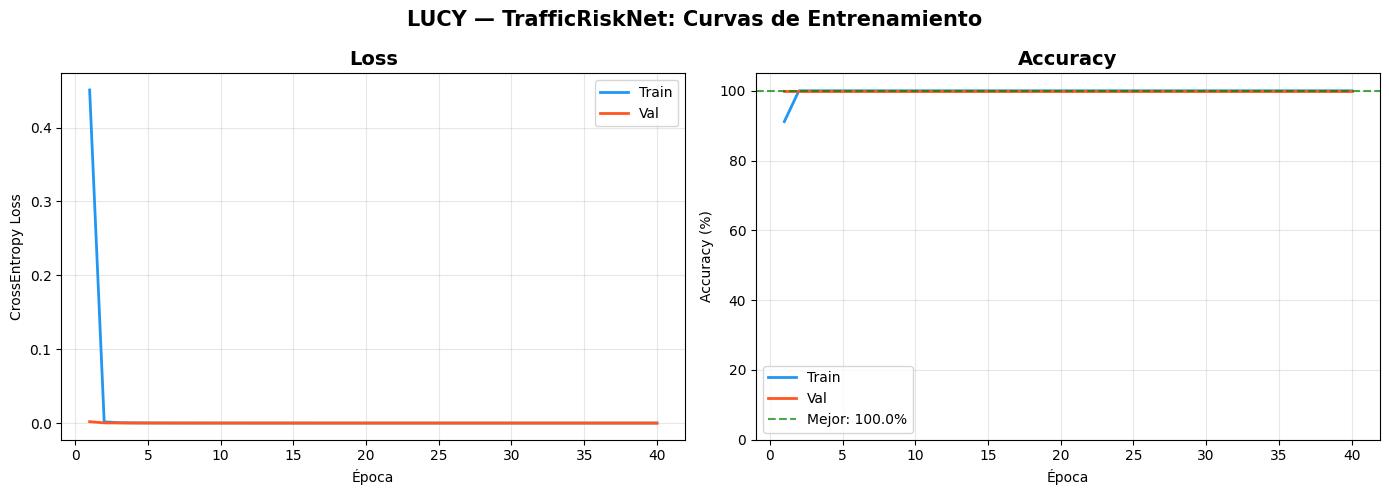

Guardado en output/traffic_learning_curves.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='#FF5722', linewidth=2)
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   color='#FF5722', linewidth=2)
axes[1].axhline(y=best_val_acc*100, color='green', linestyle='--', alpha=0.7,
                label=f'Mejor: {best_val_acc*100:.1f}%')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 105)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LUCY — TrafficRiskNet: Curvas de Entrenamiento', fontsize=15, fontweight='bold')
plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/traffic_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado en output/traffic_learning_curves.png')

## 9. Evaluación en Test — Matriz de Confusión

Test Accuracy: 100.0%

              precision    recall  f1-score   support

        SAFE       1.00      1.00      1.00       101
     WARNING       1.00      1.00      1.00        98
    CRITICAL       1.00      1.00      1.00       101

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



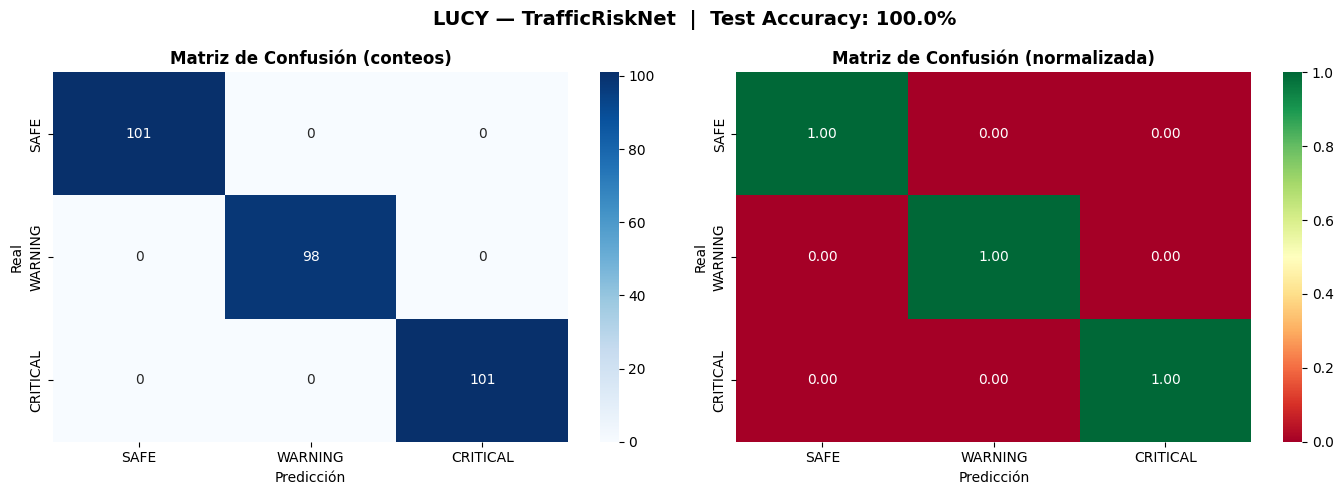

In [11]:
# Cargar el mejor modelo
model.load_state_dict(torch.load('models/traffic_risk_best.pth', map_location=DEVICE))
model.eval()

all_preds, all_true = [], []
with torch.no_grad():
    for tokens, masks, labels in test_dl:
        tokens, masks = tokens.to(DEVICE), masks.to(DEVICE)
        out = model(tokens, masks)
        all_preds.extend(out['logits'].argmax(-1).cpu().tolist())
        all_true.extend(labels.tolist())

test_acc = sum(p == t for p, t in zip(all_preds, all_true)) / len(all_true)
print(f'Test Accuracy: {test_acc*100:.1f}%\n')
print(classification_report(all_true, all_preds, target_names=RISK_CLASSES))

cm = confusion_matrix(all_true, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=RISK_CLASSES, yticklabels=RISK_CLASSES)
axes[0].set_title('Matriz de Confusión (conteos)', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1],
            xticklabels=RISK_CLASSES, yticklabels=RISK_CLASSES, vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusión (normalizada)', fontweight='bold')
axes[1].set_xlabel('Predicción'); axes[1].set_ylabel('Real')

plt.suptitle(f'LUCY — TrafficRiskNet  |  Test Accuracy: {test_acc*100:.1f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/traffic_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Demo — predicción sobre secuencias de ejemplo

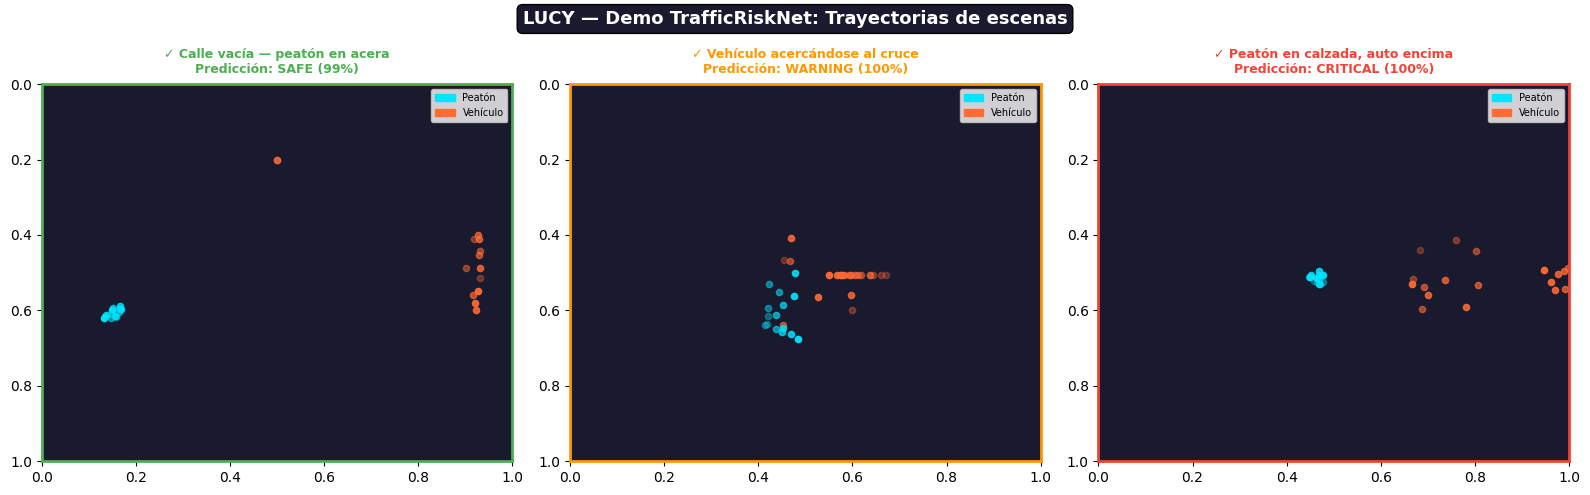

In [12]:
COLORS = {'SAFE': '#4CAF50', 'WARNING': '#FF9800', 'CRITICAL': '#F44336'}

test_cases = [
    ('Calle vacía — peatón en acera',          gen_safe_sequence(rng),     'SAFE'),
    ('Vehículo acercándose al cruce',           gen_warning_sequence(rng),  'WARNING'),
    ('Peatón en calzada, auto encima',          gen_critical_sequence(rng), 'CRITICAL'),
]

fig, axes = plt.subplots(1, len(test_cases), figsize=(16, 5))

for i, (desc, seq, expected) in enumerate(test_cases):
    # Convertir para predict()
    dets_seq = []
    for frame_dets in seq:
        frame_px = []
        for d in frame_dets:
            b = d['bbox']
            frame_px.append({
                'class_id':   d['class_id'],
                'confidence': d['confidence'],
                'bbox': [b[0]*640, b[1]*640, b[2]*640, b[3]*640]
            })
        dets_seq.append(frame_px)

    result = model.predict(dets_seq)
    pred   = result['risk_level']
    conf   = result['confidence']
    color  = COLORS[pred]

    ax = axes[i]
    ax.set_facecolor('#1a1a2e')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.invert_yaxis()

    # Dibujar trayectorias de cada frame
    for t, frame_dets in enumerate(seq):
        alpha = 0.3 + 0.7 * (t / SEQ_LEN)
        for d in frame_dets:
            b  = d['bbox']
            cx = (b[0]+b[2])/2; cy = (b[1]+b[3])/2
            c  = '#00E5FF' if d['class_id'] == COCO_PERSON else '#FF6B35'
            ax.scatter(cx, cy, s=20, color=c, alpha=alpha)

    ok = '✓' if pred == expected else '✗'
    ax.set_title(f'{ok} {desc}\nPredicción: {pred} ({conf*100:.0f}%)',
                 color=color, fontsize=9, fontweight='bold', pad=8)

    legend = [mpatches.Patch(color='#00E5FF', label='Peatón'),
              mpatches.Patch(color='#FF6B35', label='Vehículo')]
    ax.legend(handles=legend, loc='upper right', fontsize=7)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)

plt.suptitle('LUCY — Demo TrafficRiskNet: Trayectorias de escenas',
             fontsize=13, fontweight='bold', color='white',
             bbox=dict(boxstyle='round', facecolor='#1a1a2e'))
plt.tight_layout()
plt.savefig('output/traffic_demo.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## 11. Exportar a ONNX (para UE5)

In [ ]:
model.eval()
dummy_tokens = torch.zeros(1, SEQ_LEN, MAX_OBJECTS, 6).to(DEVICE)
dummy_masks  = torch.zeros(1, SEQ_LEN, MAX_OBJECTS, dtype=torch.bool).to(DEVICE)

try:
    torch.onnx.export(
        model,
        (dummy_tokens, dummy_masks),
        'models/traffic_risk_net.onnx',
        input_names  = ['tokens_seq', 'masks_seq'],
        output_names = ['logits', 'probs'],
        dynamic_axes = {
            'tokens_seq': {0: 'batch'},
            'masks_seq':  {0: 'batch'},
            'logits':     {0: 'batch'},
            'probs':      {0: 'batch'},
        },
        opset_version = 17
    )
    print('Modelo exportado → models/traffic_risk_net.onnx')
    print('Listo para integrar con UE5 NNE Plugin')
except Exception as e:
    print(f'ONNX export omitido: {e}')
    print('El .pth está disponible para el servidor Python')

## Resumen del modelo

| Componente | Arquitectura | Parámetros |
|---|---|---|
| **SpatialRiskTransformer** | TransformerEncoder (3 capas, 4 heads, d=64) + CLS token | ~150K |
| **GRUTemporalEncoder** | BiGRU (2 capas, hidden=128) + MLP clasificador | ~200K |
| **TrafficRiskNet (total)** | Spatial → GRU → SAFE/WARNING/CRITICAL | ~350K |

### Por qué GRU y no LSTM
- Secuencias cortas (15 frames) → GRU y LSTM dan resultados similares
- GRU tiene **33% menos parámetros** → más rápido para inferencia en tiempo real
- GRU usa 2 gates (reset + update) vs 3 del LSTM → más simple, menos sobreajuste

### Por qué esta arquitectura en dos etapas
El Transformer ve **un frame**: aprende relaciones espaciales entre objetos (peatón ↔ auto ↔ semáforo)  
El GRU ve **la secuencia**: aprende cómo evoluciona la escena (auto frenando vs acelerando, peatón acercándose al cruce)